# Summary Figure — Predicting Ocean pCO₂ from Satellite Data

This notebook generates a single **6-panel summary figure** that tells the full story of the project,
from geographic context through data exploration to ML results.

**Panels:**
- **(A)** Map of the 7 NOAA buoy sites
- **(B)** SST vs pCO₂ scatter — the core physical relationship
- **(C)** Data availability timeline by site
- **(D)** Model comparison (RMSE & R²)
- **(E)** Predicted vs Actual for the best model
- **(F)** Feature importance from Random Forest

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

import cartopy.crs as ccrs
import cartopy.feature as cfeature

sns.set_theme(style="whitegrid", font_scale=1.0)

PROJECT_ROOT = Path(r"C:\Users\Owner\OneDrive - UW\Desktop\Grad School\coursework\machine learning\Geoceanographers\TeamProject\GeOceanProject")
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
PLOT_DIR = PROJECT_ROOT / "plots"
PLOT_DIR.mkdir(parents=True, exist_ok=True)

print("Ready.")

Ready.


In [2]:
# ──────────────────────────────────────────────
# Load all data needed for the 6 panels
# ──────────────────────────────────────────────

# 1) ML-ready training data (for panels A, B, D, E, F)
df = pd.read_csv(PROCESSED_DIR / "training_data_700_ml_ready.csv")
df["date"] = pd.to_datetime(df["date"])

# 2) Continuous data periods (for panel C — data availability)
periods = pd.read_csv(PROCESSED_DIR / "buoy_continuous_data_periods.csv")
periods["segment_start"] = pd.to_datetime(periods["segment_start"])
periods["segment_end"]   = pd.to_datetime(periods["segment_end"])

# Quick reference: one lat/lon per site
site_coords = (
    df.groupby("location")[["latitude", "longitude"]]
    .median()
    .reset_index()
)

print(f"Training data: {len(df)} rows, {df['location'].nunique()} sites")
print(f"Data periods:  {len(periods)} continuous segments")
print()
print(site_coords.to_string(index=False))

Training data: 479 rows, 7 sites
Data periods:  35 continuous segments

           location  latitude  longitude
      First Landing    36.998    -76.088
 Grays Reef Georgia    31.399    -80.869
            LA Buoy    28.869    -90.480
            La Push    47.964   -124.958
      SE Bering Sea    56.865   -164.065
      South Pacific    -0.001   -154.919
Southern California    34.308   -120.814


In [3]:
# ──────────────────────────────────────────────
# Re-train models (quick — needed for panels D, E, F)
# ──────────────────────────────────────────────

FEATURE_COLS = [
    "latitude", "longitude", "sst_in_situ_mean",
    "sat_sst_mean", "sat_sst_std", "sat_sst_min", "sat_sst_max",
    "sat_sst_median", "sat_sst_closest",
    "sat_chla_mean", "sat_chla_std", "sat_chla_min", "sat_chla_max",
    "sat_chla_median", "sat_chla_closest", "chla_days_offset",
]
TARGET = "pco2_mean"

X = df[FEATURE_COLS].copy()
y = df[TARGET].copy()
X = X.fillna(X.median())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=df["location"]
)

scaler = StandardScaler()
X_train_sc = pd.DataFrame(scaler.fit_transform(X_train), columns=FEATURE_COLS, index=X_train.index)
X_test_sc  = pd.DataFrame(scaler.transform(X_test),      columns=FEATURE_COLS, index=X_test.index)

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(
        n_estimators=200, max_depth=12, min_samples_leaf=5,
        random_state=42, n_jobs=-1),
}

results = []
predictions = {}

for name, model in models.items():
    if "Linear" in name:
        model.fit(X_train_sc, y_train)
        y_pred = model.predict(X_test_sc)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    rmse = mean_squared_error(y_test, y_pred) ** 0.5
    mae  = mean_absolute_error(y_test, y_pred)
    r2   = r2_score(y_test, y_pred)
    results.append({"Model": name, "RMSE": round(rmse, 1), "MAE": round(mae, 1), "R2": round(r2, 3)})
    predictions[name] = y_pred
    print(f"{name:25s}  RMSE={rmse:.1f}  MAE={mae:.1f}  R²={r2:.3f}")

results_df = pd.DataFrame(results)
best_name = results_df.loc[results_df["RMSE"].idxmin(), "Model"]
print(f"\nBest model: {best_name}")

Linear Regression          RMSE=83.3  MAE=55.6  R²=0.281
Random Forest              RMSE=71.8  MAE=43.6  R²=0.465

Best model: Random Forest


c:\Users\Owner\.conda\envs\mlgeo\Lib\site-packages\cartopy\mpl\feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
C:\Users\Owner\AppData\Local\Temp\ipykernel_11088\1785282827.py:212: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.savefig(save_path, dpi=200, bbox_inches="tight", facecolor="white")
C:\Users\Owner\AppData\Local\Temp\ipykernel_11088\1785282827.py:212: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.savefig(save_path, dpi=200, bbox_inches="tight", facecolor="white")
c:\Users\Owner\.conda\envs\mlgeo\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Owner\.conda\envs\mlgeo\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(

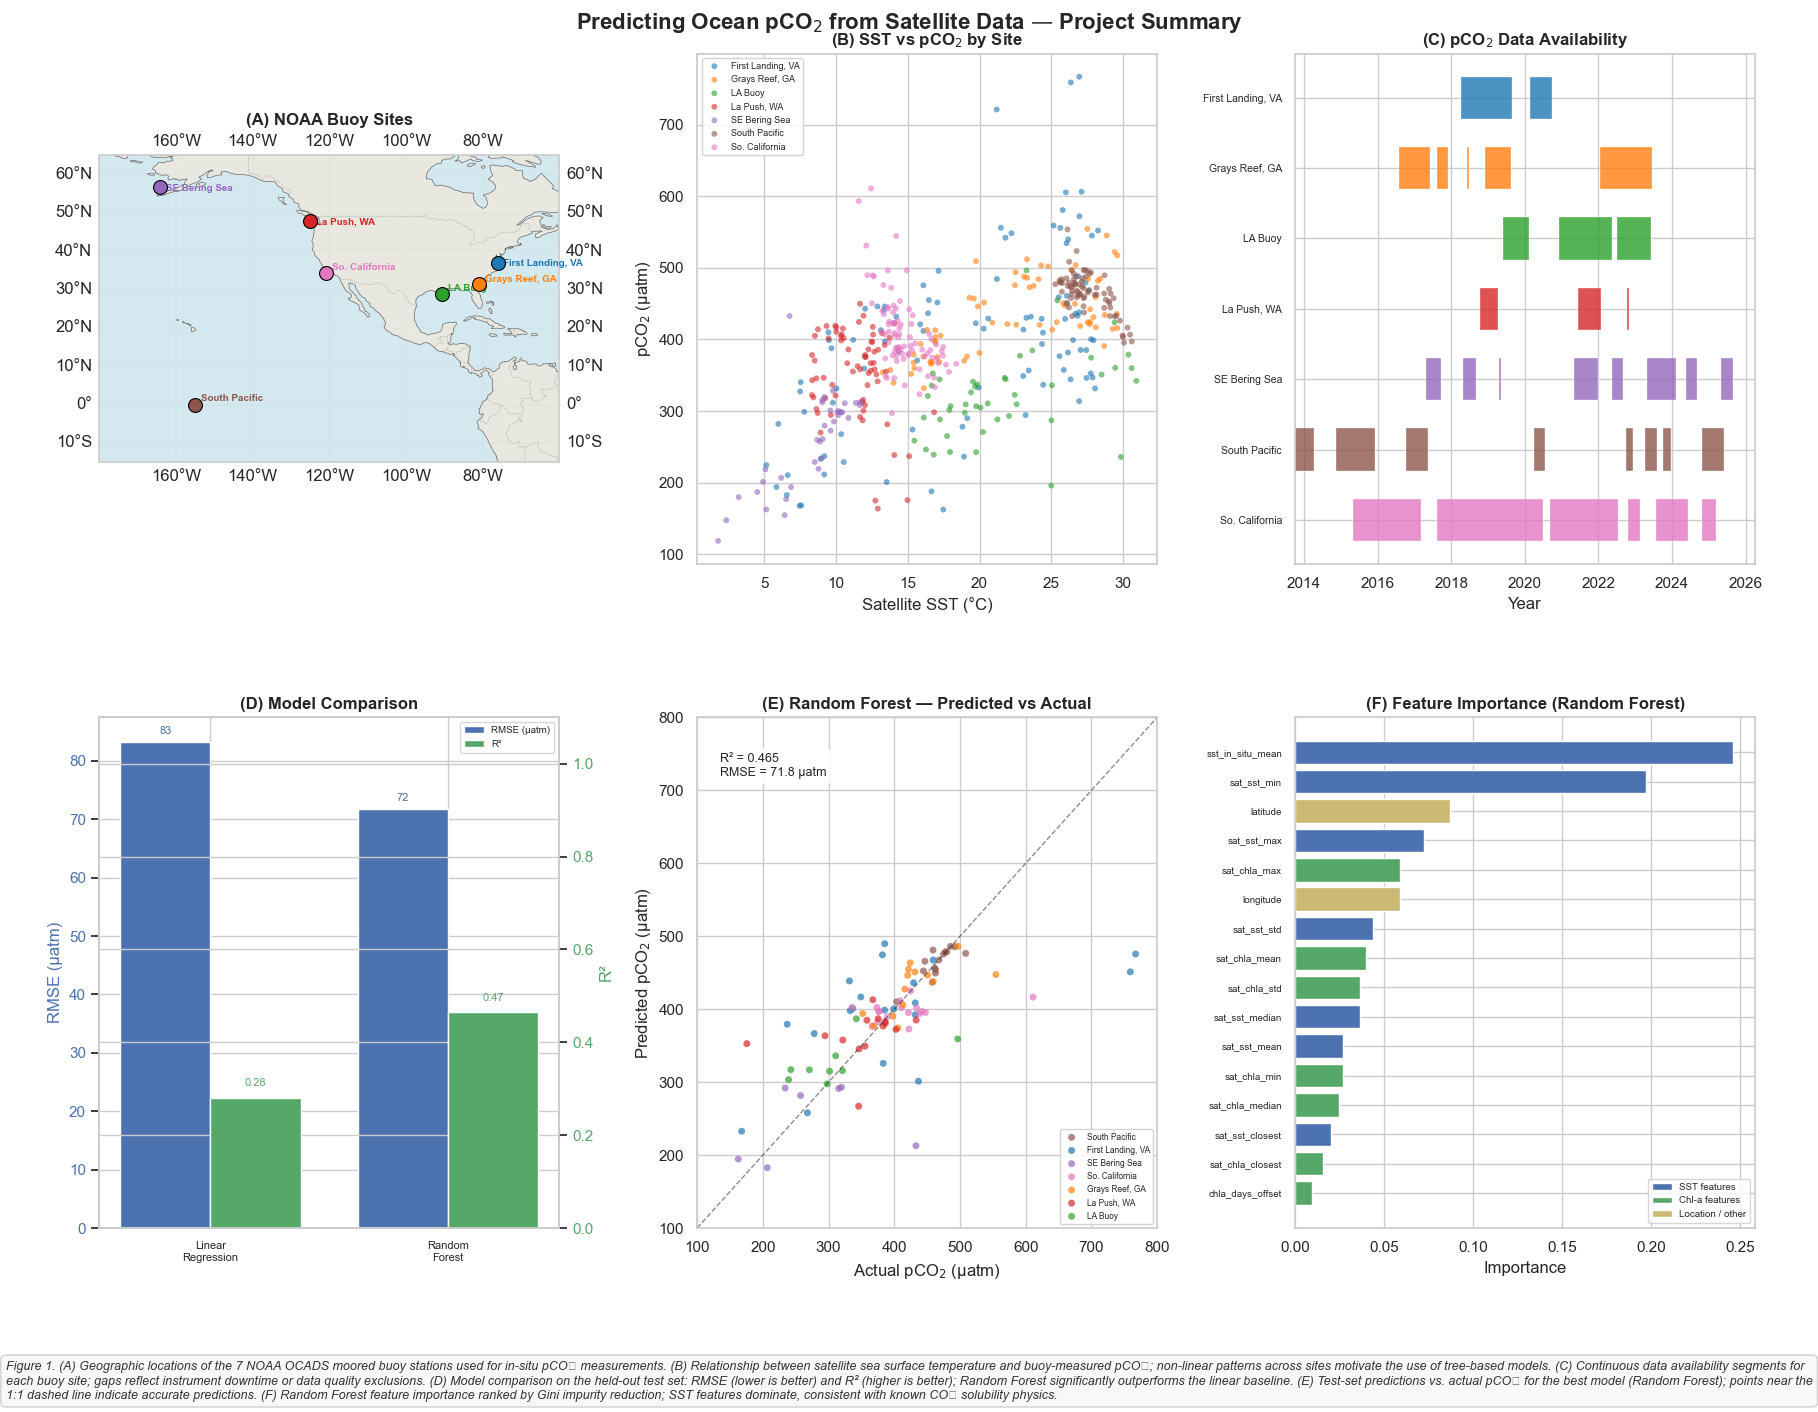


Saved → C:\Users\Owner\OneDrive - UW\Desktop\Grad School\coursework\machine learning\Geoceanographers\TeamProject\GeOceanProject\plots\summary_figure_6panel.png


In [5]:
# ══════════════════════════════════════════════════════════════
#  BUILD THE 6-PANEL SUMMARY FIGURE  (2 rows × 3 columns)
# ══════════════════════════════════════════════════════════════

# Panel A needs a cartopy projection, so we build the gridspec manually
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Patch

projection = ccrs.PlateCarree()

fig = plt.figure(figsize=(18, 14.5))
gs = GridSpec(2, 3, figure=fig, hspace=0.30, wspace=0.30,
              top=0.94, bottom=0.13, left=0.05, right=0.97)

fig.suptitle("Predicting Ocean pCO$_2$ from Satellite Data — Project Summary",
             fontsize=16, fontweight="bold", y=0.97)

palette = dict(zip(
    site_coords["location"],
    sns.color_palette("tab10", n_colors=len(site_coords))
))

# Short display names for cleaner labels
short_names = {
    "First Landing": "First Landing, VA",
    "Grays Reef Georgia": "Grays Reef, GA",
    "LA Buoy": "LA Buoy",
    "La Push": "La Push, WA",
    "SE Bering Sea": "SE Bering Sea",
    "South Pacific": "South Pacific",
    "Southern California": "So. California",
}

# ── Panel A: Map of buoy sites (real coastline) ─────────────
ax_a = fig.add_subplot(gs[0, 0], projection=projection)
ax_a.set_extent([-180, -60, -15, 65], crs=projection)
ax_a.add_feature(cfeature.LAND, facecolor="#e8e8e0", edgecolor="none")
ax_a.add_feature(cfeature.OCEAN, facecolor="#d4e8f0")
ax_a.add_feature(cfeature.COASTLINE, linewidth=0.5, color="#666666")
ax_a.add_feature(cfeature.BORDERS, linewidth=0.3, linestyle="--", color="#999999")
ax_a.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5,
               xlocs=range(-180, -50, 20), ylocs=range(-10, 70, 10),
               x_inline=False, y_inline=False)

for _, row in site_coords.iterrows():
    loc = row["location"]
    ax_a.scatter(row["longitude"], row["latitude"],
                s=100, color=palette[loc], edgecolors="black",
                linewidths=0.8, zorder=5, transform=projection)
    offset_x, offset_y = 4, 2
    if "Bering" in loc:
        offset_x, offset_y = 4, -3
    elif "South Pacific" in loc:
        offset_x, offset_y = 4, 2.5
    elif "La Push" in loc:
        offset_x, offset_y = 4, -2.5
    elif "Southern" in loc:
        offset_x, offset_y = 4, 2.5
    elif "First" in loc:
        offset_x, offset_y = 4, -2.5
    elif "LA Buoy" in loc:
        offset_x, offset_y = 4, 2
    ax_a.annotate(short_names.get(loc, loc),
                 xy=(row["longitude"], row["latitude"]),
                 xytext=(offset_x, offset_y), textcoords="offset points",
                 fontsize=7, fontweight="bold", color=palette[loc],
                 transform=projection)

ax_a.set_title("(A) NOAA Buoy Sites", fontweight="bold")

# ── Panel B: SST vs pCO₂ scatter ───────────────────────────
ax_b = fig.add_subplot(gs[0, 1])
for loc in df["location"].unique():
    sub = df[df["location"] == loc]
    ax_b.scatter(sub["sat_sst_mean"], sub["pco2_mean"],
                s=18, alpha=0.6, color=palette[loc],
                label=short_names.get(loc, loc), edgecolors="none")
ax_b.set_xlabel("Satellite SST (°C)")
ax_b.set_ylabel("pCO$_2$ (µatm)")
ax_b.set_title("(B) SST vs pCO$_2$ by Site", fontweight="bold")
ax_b.legend(fontsize=6.5, loc="upper left", framealpha=0.85, ncol=1)

# ── Panel C: Data availability timeline ─────────────────────
ax_c = fig.add_subplot(gs[0, 2])
locations_sorted = sorted(periods["location"].unique())
y_positions = {loc: i for i, loc in enumerate(locations_sorted)}

for _, row in periods.iterrows():
    loc = row["location"]
    y_pos = y_positions[loc]
    ax_c.barh(y_pos, (row["segment_end"] - row["segment_start"]).days,
             left=row["segment_start"], height=0.6,
             color=palette[loc], alpha=0.8, edgecolor="white", linewidth=0.3)

ax_c.set_yticks(range(len(locations_sorted)))
ax_c.set_yticklabels([short_names.get(l, l) for l in locations_sorted], fontsize=7.5)
ax_c.xaxis.set_major_locator(mdates.YearLocator(2))
ax_c.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax_c.set_xlabel("Year")
ax_c.set_title("(C) pCO$_2$ Data Availability", fontweight="bold")
ax_c.invert_yaxis()

# ── Panel D: Model comparison bar chart ─────────────────────
ax_d = fig.add_subplot(gs[1, 0])
x_pos = np.arange(len(results_df))
bar_w = 0.38

bars1 = ax_d.bar(x_pos - bar_w/2, results_df["RMSE"], bar_w,
                label="RMSE (µatm)", color="#4c72b0", edgecolor="white")

ax_d2 = ax_d.twinx()
bars2 = ax_d2.bar(x_pos + bar_w/2, results_df["R2"], bar_w,
                 label="R²", color="#55a868", edgecolor="white")
ax_d2.set_ylim(0, 1.1)
ax_d2.set_ylabel("R²", color="#55a868")
ax_d2.tick_params(axis="y", labelcolor="#55a868")

ax_d.set_xticks(x_pos)
ax_d.set_xticklabels(["Linear\nRegression", "Random\nForest"], fontsize=8)
ax_d.set_ylabel("RMSE (µatm)", color="#4c72b0")
ax_d.tick_params(axis="y", labelcolor="#4c72b0")
ax_d.set_title("(D) Model Comparison", fontweight="bold")

for bar in bars1:
    ax_d.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f"{bar.get_height():.0f}", ha="center", va="bottom", fontsize=8, color="#4c72b0")
for bar in bars2:
    ax_d2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
              f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=8, color="#55a868")

lines = [bars1, bars2]
labels = ["RMSE (µatm)", "R²"]
ax_d.legend(lines, labels, loc="upper right", fontsize=7)

# ── Panel E: Predicted vs Actual (best model) ──────────────
ax_e = fig.add_subplot(gs[1, 1])
best_pred = predictions[best_name]
best_r2   = r2_score(y_test, best_pred)
best_rmse = mean_squared_error(y_test, best_pred) ** 0.5

test_locs = df.loc[X_test.index, "location"]
for loc in test_locs.unique():
    mask = test_locs == loc
    ax_e.scatter(y_test[mask], best_pred[mask.values],
                s=25, alpha=0.7, color=palette[loc],
                label=short_names.get(loc, loc), edgecolors="none")

lims = [100, 800]
ax_e.plot(lims, lims, "k--", lw=1, alpha=0.5)
ax_e.set_xlim(lims); ax_e.set_ylim(lims)
ax_e.set_xlabel("Actual pCO$_2$ (µatm)")
ax_e.set_ylabel("Predicted pCO$_2$ (µatm)")
ax_e.set_title(f"(E) {best_name} — Predicted vs Actual", fontweight="bold")
ax_e.text(0.05, 0.93, f"R² = {best_r2:.3f}\nRMSE = {best_rmse:.1f} µatm",
         transform=ax_e.transAxes, fontsize=9, va="top",
         bbox=dict(boxstyle="round", fc="white", alpha=0.85))
ax_e.legend(fontsize=6, loc="lower right", framealpha=0.85)

# ── Panel F: Feature importance ─────────────────────────────
ax_f = fig.add_subplot(gs[1, 2])
rf = models["Random Forest"]
feat_imp = pd.DataFrame({
    "feature": FEATURE_COLS,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=True)

def feat_color(name):
    if "sst" in name.lower():
        return "#4c72b0"
    elif "chl" in name.lower():
        return "#55a868"
    else:
        return "#ccb974"

colors = [feat_color(f) for f in feat_imp["feature"]]
ax_f.barh(feat_imp["feature"], feat_imp["importance"], color=colors, edgecolor="white")
ax_f.set_xlabel("Importance")
ax_f.set_title("(F) Feature Importance (Random Forest)", fontweight="bold")
ax_f.tick_params(axis="y", labelsize=7)

legend_elements = [
    Patch(facecolor="#4c72b0", label="SST features"),
    Patch(facecolor="#55a868", label="Chl-a features"),
    Patch(facecolor="#ccb974", label="Location / other"),
]
ax_f.legend(handles=legend_elements, fontsize=7, loc="lower right")

# ── Combined figure caption below all panels ────────────────
caption = (
    "Figure 1. "
    "(A) Geographic locations of the 7 NOAA OCADS moored buoy stations used for in-situ pCO₂ measurements. "
    "(B) Relationship between satellite sea surface temperature and buoy-measured pCO₂; "
    "non-linear patterns across sites motivate the use of tree-based models. "
    "(C) Continuous data availability segments for each buoy site; gaps reflect instrument downtime "
    "or data quality exclusions. "
    "(D) Model comparison on the held-out test set: RMSE (lower is better) and R² (higher is better); "
    "Random Forest significantly outperforms the linear baseline. "
    "(E) Test-set predictions vs. actual pCO₂ for the best model (Random Forest); "
    "points near the 1:1 dashed line indicate accurate predictions. "
    "(F) Random Forest feature importance ranked by Gini impurity reduction; "
    "SST features dominate, consistent with known CO₂ solubility physics."
)

fig.text(0.50, 0.01, caption, ha="center", va="bottom", fontsize=9,
         fontstyle="italic", color="#333333",
         wrap=True, transform=fig.transFigure,
         multialignment="left",
         bbox=dict(boxstyle="round,pad=0.4", fc="#f8f8f8", ec="#cccccc", alpha=0.9))

# ── Save ────────────────────────────────────────────────────
save_path = PLOT_DIR / "summary_figure_6panel.png"
fig.savefig(save_path, dpi=200, bbox_inches="tight", facecolor="white")
plt.show()
print(f"\nSaved → {save_path}")